In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185,

In [2]:
import importlib
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import wine_common as wine
import knn_common as kc
from sklearn.metrics import ConfusionMatrixDisplay, classification_report



In [3]:
importlib.reload(wine)
importlib.reload(kc)

<module 'knn_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/monk/knn_common.py'>

In [4]:
# Split for KFold
n_split = 5
default_cv = StratifiedKFold(n_splits=n_split, shuffle=True, random_state=42)

default_krange = list(range(1, 41, 2))


<h2>Wine Dataset</h2>
<hr/>

<h4>Data Loading</h4>
<p>Load and introspect data from monk training and test set.</p>

In [5]:
importlib.reload(wine)
df_train, df_test = wine.stratified_split()
X_tr, y_tr, X_ts, y_ts = wine.split_and_prepare_dataset(df_train, df_test)
wine.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,5199,1298
1,Number of features,11,11
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 3919, class 1 = 1280","class 0 = 979, class 1 = 319"


In [6]:
model, cv_scores, train_scores = kc.find_best_knn_model(
    X_tr, y_tr, default_cv, default_krange
)

kc.knn_introspection(cv_scores)


Best k: 1
Best mean accuracy: 0.9932679351447398
Std: 0.002192646579424865


(1, np.float64(0.9932679351447398), np.float64(0.002192646579424865))

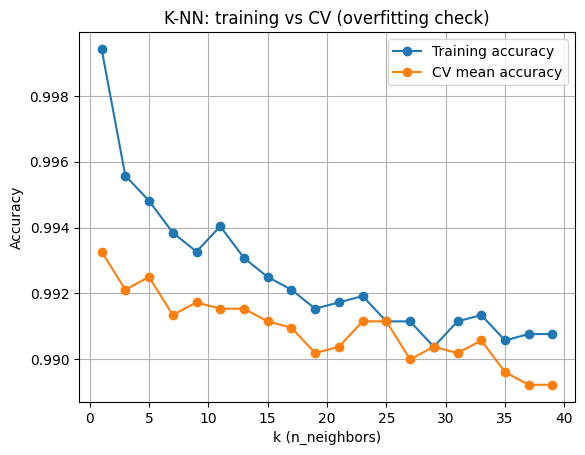

In [7]:
kc.plot_knn_validation_curve(cv_scores, train_scores)

<h4>Prediction</h4>
<p>Performing a prediction on the test set</p>

In [8]:
model.fit(X_tr, y_tr)
y_pred = model.predict(X_ts)

In [9]:
print(classification_report(y_ts, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.87      0.93       979
           1       0.72      0.99      0.83       319

    accuracy                           0.90      1298
   macro avg       0.86      0.93      0.88      1298
weighted avg       0.93      0.90      0.91      1298



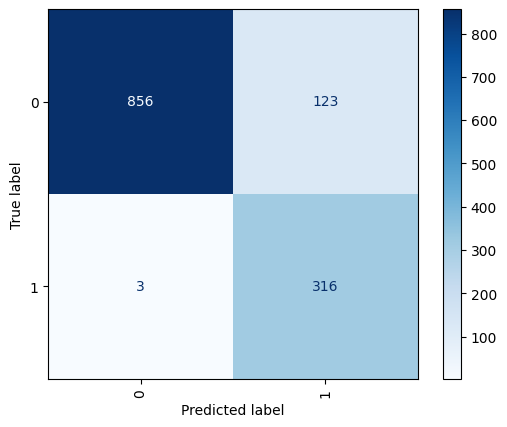

In [10]:
ConfusionMatrixDisplay.from_predictions(y_ts, y_pred, xticks_rotation='vertical', cmap='Blues');